In [40]:
import ultranest
import george
import numpy as np
import matplotlib.pyplot as plt
from ultranest.plot import cornerplot
from ultranest import ReactiveNestedSampler

In [93]:
filename = 'Land_and_Ocean_complete.txt'
separator = "% Global Average Temperature Anomaly with Sea Ice Temperature Inferred from Water Temperatures"

with open(filename, 'r') as f:
    content = f.read()

parts = content.split(separator)

with open('data_air.txt', 'w') as f:
    f.write(parts[0])

with open('data_water.txt', 'w') as f:
    f.write(separator + parts[1])

data_air_raw = np.genfromtxt('data_air.txt', comments='%', filling_values=np.nan)
data_water_raw = np.genfromtxt('data_water.txt', comments='%', filling_values=np.nan)

print("File creati e caricati correttamente!")
data_t = np.arange(0, 2100)
def to_dict(raw, data_t):
    return {
        "fake_time": data_t,
        "Year": raw[:,0].astype(int), 
        "Month": raw[:,1].astype(int), 
        "Monthly_Anomaly": raw[:,2], 
        "Monthly_Anomaly_Unc": raw[:,3], 
        "Annual_Anomaly": raw[:,4], 
        "Annual_Anomaly_Unc": raw[:,5], 
        "Five_Year_Anomaly": raw[:,6], 
        "Five_Year_Anomaly_Unc": raw[:,7], 
        "Ten_Year_Anomaly": raw[:,8], 
        "Ten_Year_Anomaly_Unc": raw[:,9], 
        "Twenty_Year_Anomaly": raw[:,10], 
        "Twenty_Year_Anomaly_Unc": raw[:,11], 
    }

data_air = to_dict(data_air_raw, data_t)
data_water = to_dict(data_water_raw, data_t)
print(data_air.keys())

print(f"Mesi caricati (Sezione Aria): {len(data_air['Year'])}")
print(f"Mesi caricati (Sezione Acqua): {len(data_water['Year'])}")

File creati e caricati correttamente!
dict_keys(['fake_time', 'Year', 'Month', 'Monthly_Anomaly', 'Monthly_Anomaly_Unc', 'Annual_Anomaly', 'Annual_Anomaly_Unc', 'Five_Year_Anomaly', 'Five_Year_Anomaly_Unc', 'Ten_Year_Anomaly', 'Ten_Year_Anomaly_Unc', 'Twenty_Year_Anomaly', 'Twenty_Year_Anomaly_Unc'])
Mesi caricati (Sezione Aria): 2100
Mesi caricati (Sezione Acqua): 2100


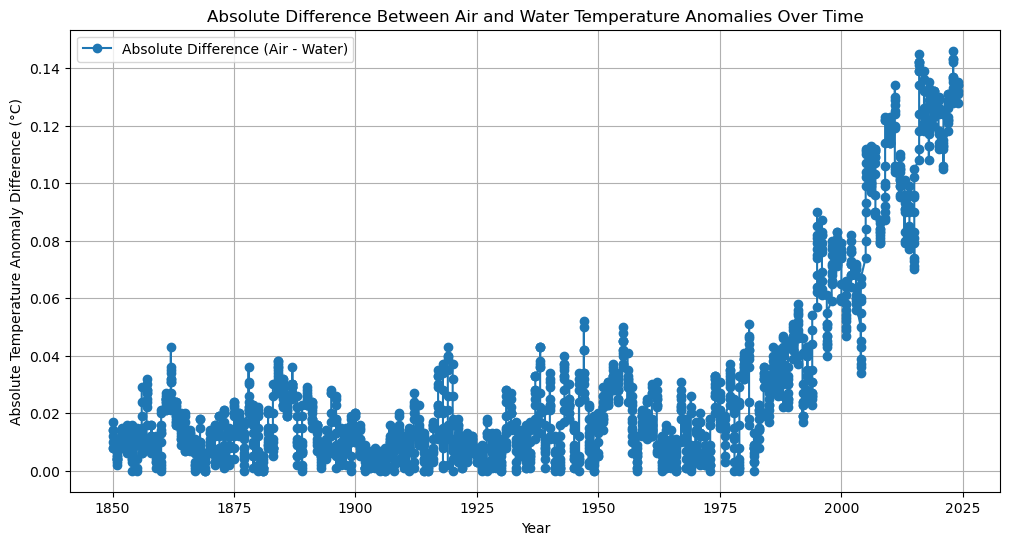

In [9]:
diff = np.abs(data_air['Annual_Anomaly'] - data_water['Annual_Anomaly'])
plt.figure(figsize=(12, 6))
plt.plot(data_air['Year'], diff, 'o-', label='Absolute Difference (Air - Water)')
plt.xlabel('Year')
plt.ylabel('Absolute Temperature Anomaly Difference (°C)')
plt.title('Absolute Difference Between Air and Water Temperature Anomalies Over Time')
plt.legend()
plt.grid()
plt.show()

In [46]:
def constant_model(t, intercept):
    return intercept + t*0

def linear_model(t, a, b):
    return b + a*t

def quadratic_model(t, a, b, c):
    return c + b*t + a*t**2

def exponential_model(t, a, b, c):
    return a * np.exp(b*t) + c

In [94]:
param_constant = ['intercept']
param_linear = ['a', 'b']
param_quadratic = ['a', 'b', 'c']
param_exponential = ['a', 'b', 'c']

def prior_constant(cube):

    params = cube.copy()

    params[0] = cube[0] * 20 - 10

    return params

def prior_linear(cube):

    params = cube.copy()

    params[0] = cube[0] * 1000 
    params[1] = cube[1] * 20 - 10

    return params


def prior_quadratic(cube):

    params = cube.copy()

    params[0] = cube[0] * 1000 
    params[1] = cube[1] * 1000 
    params[2] = cube[2] * 20 - 10

    return params

def prior_exponential(cube):

    params = cube.copy()

    params[0] = cube[0] * 10
    params[1] = cube[1] * (10/2024) 
    params[2] = cube[2] * 20 - 10

    return params

def log_likelihood_constant(params, data):
    
    intercept = params

    model = constant_model(data['Year'], intercept)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2+np.log(2*np.pi*data['Annual_Anomaly_Unc']**2))

    loglike = -0.5 * chi2

    return loglike

def log_likelihood_linear(params, data):
    
    a, b = params

    model = linear_model(data['fake_time'], a, b)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2)

    loglike = -0.5 * chi2

    return loglike

def log_likelihood_quadratic(params, data):
    
    a, b, c = params

    model = quadratic_model(data['Year'], a, b, c)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2+np.log(2*np.pi*data['Annual_Anomaly_Unc']**2))

    loglike = -0.5 * chi2

    return loglike

def log_likelihood_exponential(params, data):
    
    a, b, c = params

    model = exponential_model(data['Year'], a, b, c)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2+np.log(2*np.pi*data['Annual_Anomaly_Unc']**2))

    loglike = -0.5 * chi2

    return loglike

In [95]:
# sampler_air_const = ReactiveNestedSampler(param_constant, lambda params: log_likelihood_constant(params, data_air), prior_constant)
# result_air_const = sampler_air_const.run(min_num_live_points=400, dKL=np.inf, min_ess=100)

# sampler_water_const = ReactiveNestedSampler(param_constant, lambda params: log_likelihood_constant(params, data_water), prior_constant)
# result_water_const = sampler_water_const.run(min_num_live_points=400, dKL=np.inf, min_ess=100)

sampler_air_linear = ReactiveNestedSampler(param_linear, lambda params: log_likelihood_linear(params, data_air), prior_linear)
result_air_linear = sampler_air_linear.run(min_num_live_points=400, dKL=np.inf, min_ess=100)

sampler_water_linear = ReactiveNestedSampler(param_linear, lambda params: log_likelihood_linear(params, data_water), prior_linear)
result_water_linear = sampler_water_linear.run(min_num_live_points=400, dKL=np.inf, min_ess=100)

# sampler_air_quadratic = ReactiveNestedSampler(param_quadratic, lambda params: log_likelihood_quadratic(params, data_air), prior_quadratic)
# result_air_quadratic = sampler_air_quadratic.run(min_num_live_points=400, dKL=np.inf, min_ess=100)

# sampler_water_quadratic = ReactiveNestedSampler(param_quadratic, lambda params: log_likelihood_quadratic(params, data_water), prior_quadratic)
# result_water_quadratic = sampler_water_quadratic.run(min_num_live_points=400, dKL=np.inf, min_ess=100)

# sampler_air_exponential = ReactiveNestedSampler(param_exponential, lambda params: log_likelihood_exponential(params, data_air), prior_exponential)
# result_air_exponential = sampler_air_exponential.run(min_num_live_points=400, dKL=np.inf, min_ess=100)

# sampler_water_exponential = ReactiveNestedSampler(param_exponential, lambda params: log_likelihood_exponential(params, data_water), prior_exponential)
# result_water_exponential = sampler_water_exponential.run(min_num_live_points=400, dKL=np.inf, min_ess=100)


[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-2e+04  -20185.62 [-20185.6287..-20185.6287]*| it/evals=12920/17265 eff=76.6084% N=400   0   0 
[ultranest] Likelihood function evaluations: 17304
[ultranest]   logZ = -2.021e+04 +- 0.1659
[ultranest] Effective samples strategy satisfied (ESS = 1601.9, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.07 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.17, need <0.5)
[ultranest]   logZ error budget: single: 0.26 bs:0.17 tail:0.01 total:0.17 required:<0.50
[ultranest] done iterating.
[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-2e+04  -18230.81 [-18230.8254..-18230.8254]*| it/evals=12880/17251 eff=76.4346% N=400   0   00 
[ultranest] Likelihood function evaluations: 17307
[ultranest]   logZ = -1.826e+04 +- 0.1908
[ultranest] Effective samples strategy satisfied (ESS = 1581.8, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.09 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.19, need <0.5)
[ultranest]   logZ error budget: single: 0.26 bs:0.19 tail:0.01 total:0.19 required:<0.50
[ultranest] done iterating.


In [99]:
# sampler_air_const.print_results()
# sampler_water_const.print_results()

sampler_air_linear.print_results()
sampler_water_linear.print_results()

# sampler_air_quadratic.print_results()
# sampler_water_quadratic.print_results()

# sampler_air_exponential.print_results()
# sampler_water_exponential.print_results()


logZ = -20213.392 +- 0.429
  single instance: logZ = -20213.392 +- 0.259
  bootstrapped   : logZ = -20213.373 +- 0.429
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   0.0008354 +- 0.0000023
    b                   : -0.9839│ ▁  ▁▁▁▁▁▁▁▂▂▃▄▆▇▆▇▇▇▆▆▅▄▃▃▂▁▁▁▁▁▁▁  ▁ │-0.9501    -0.9669 +- 0.0038


logZ = -18258.511 +- 0.351
  single instance: logZ = -18258.511 +- 0.258
  bootstrapped   : logZ = -18258.492 +- 0.350
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   0.0007621 +- 0.0000022
    b                   : -0.9093│ ▁▁▁▁▁▁▁▁▁▂▂▃▄▅▅▆▇▇▇▇▆▆▅▅▄▃▂▂▁▁▁▁▁▁  ▁ │-0.8792    -0.8944 +- 0.0037



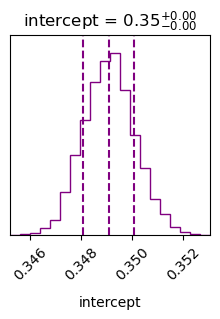

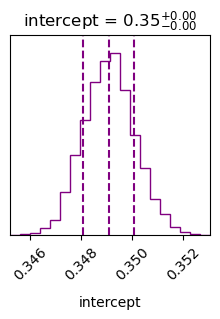

In [61]:
cornerplot(result_air_const)

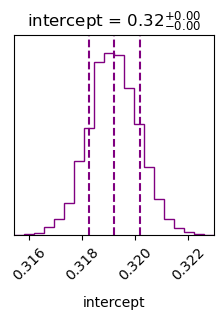

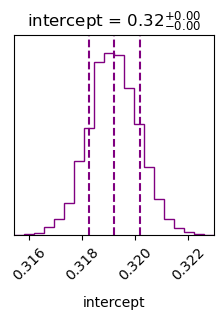

In [62]:
cornerplot(result_water_const)

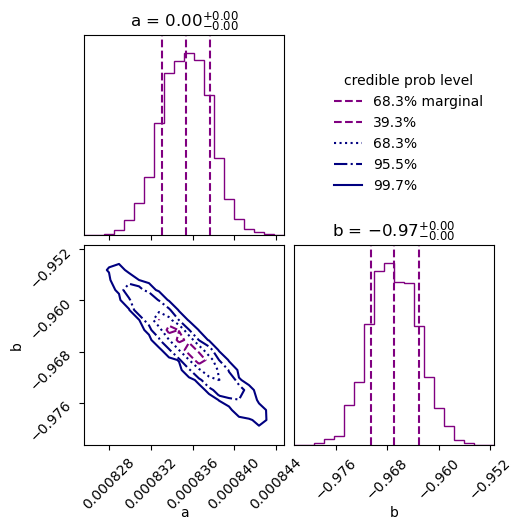

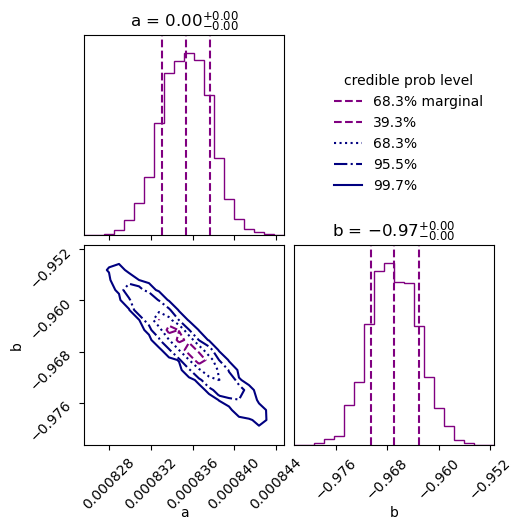

In [97]:
cornerplot(result_air_linear)

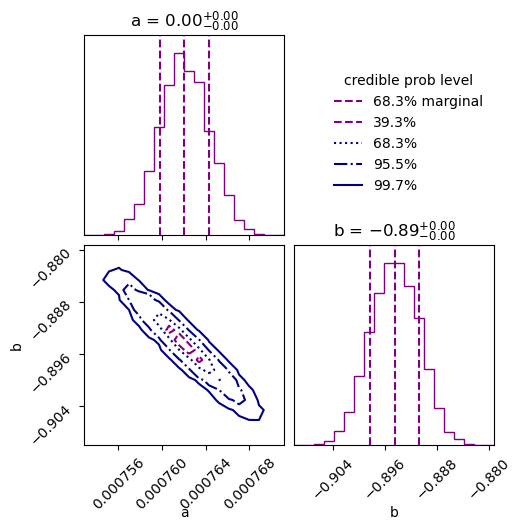

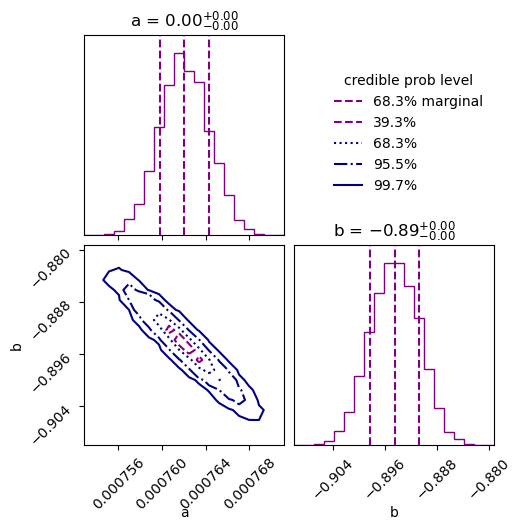

In [100]:
cornerplot(result_water_linear)

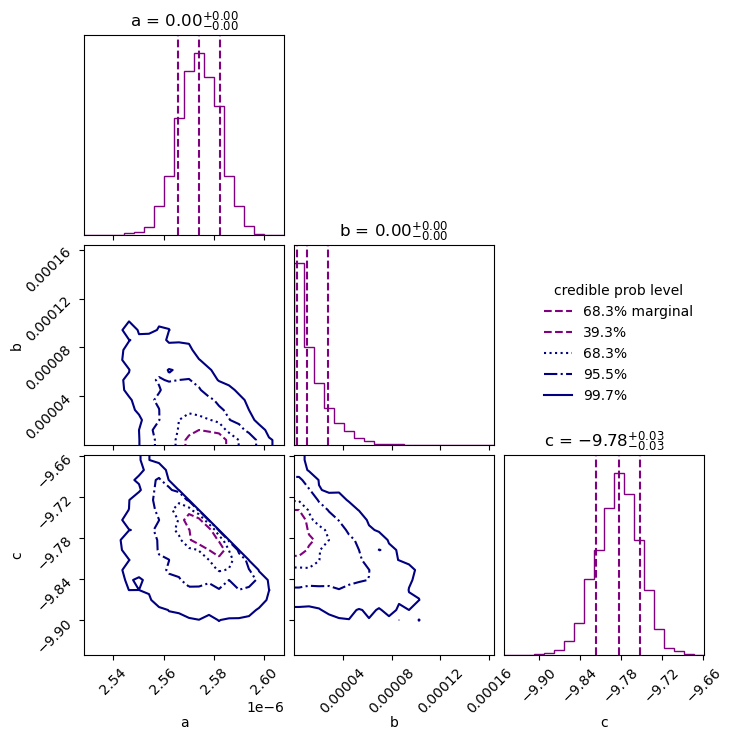

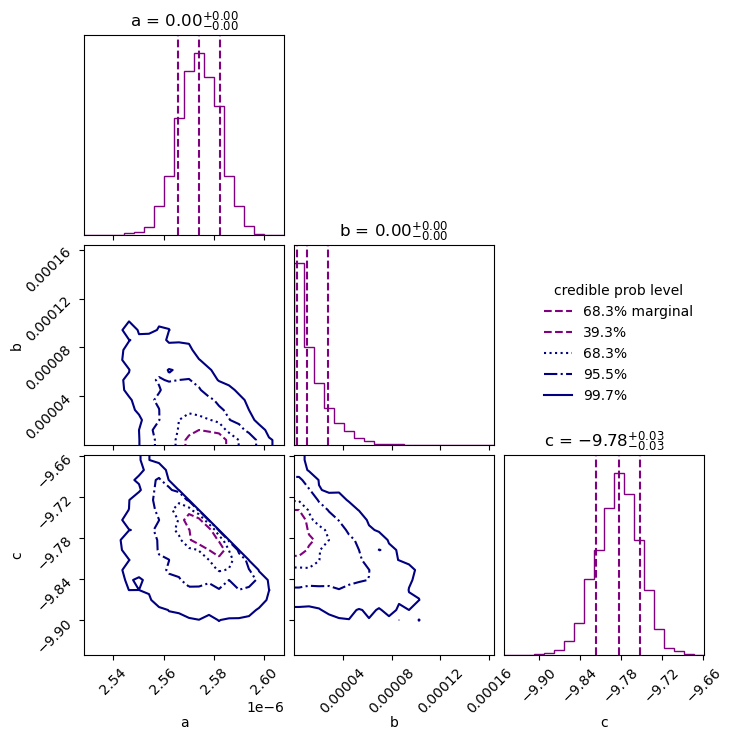

In [65]:
cornerplot(result_air_quadratic)

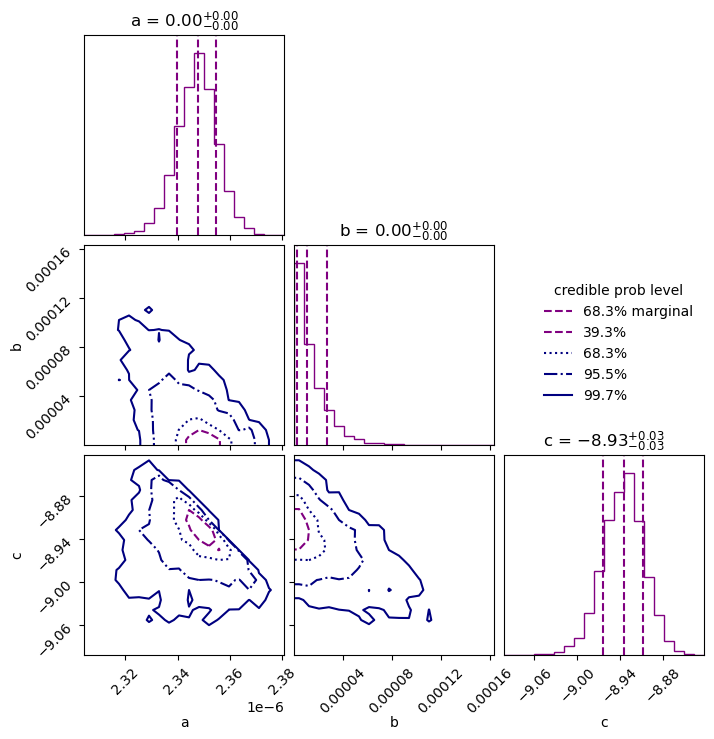

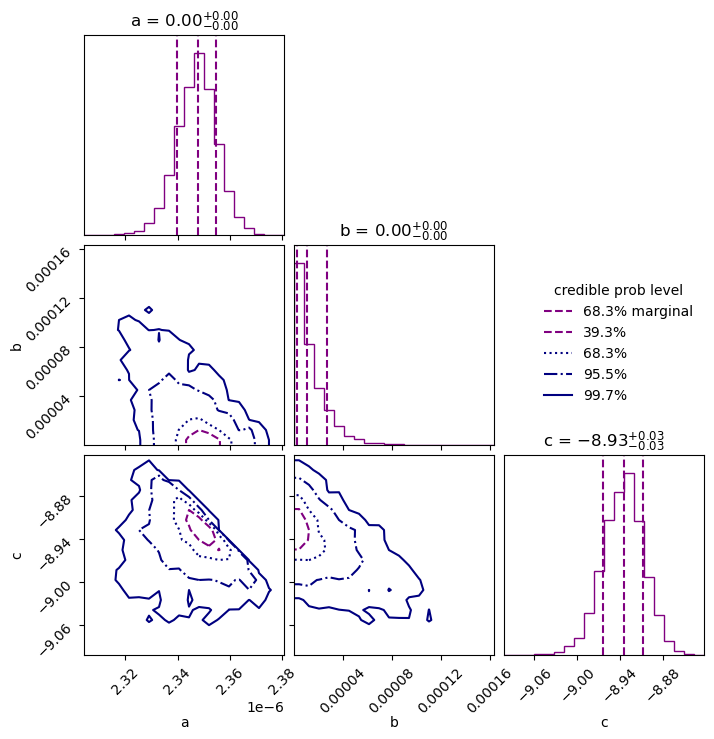

In [66]:
cornerplot(result_water_quadratic)

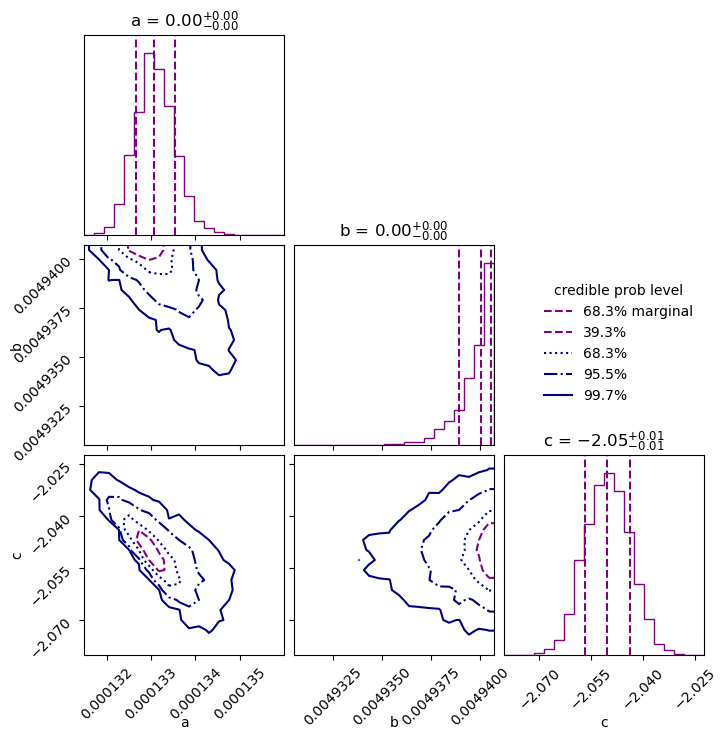

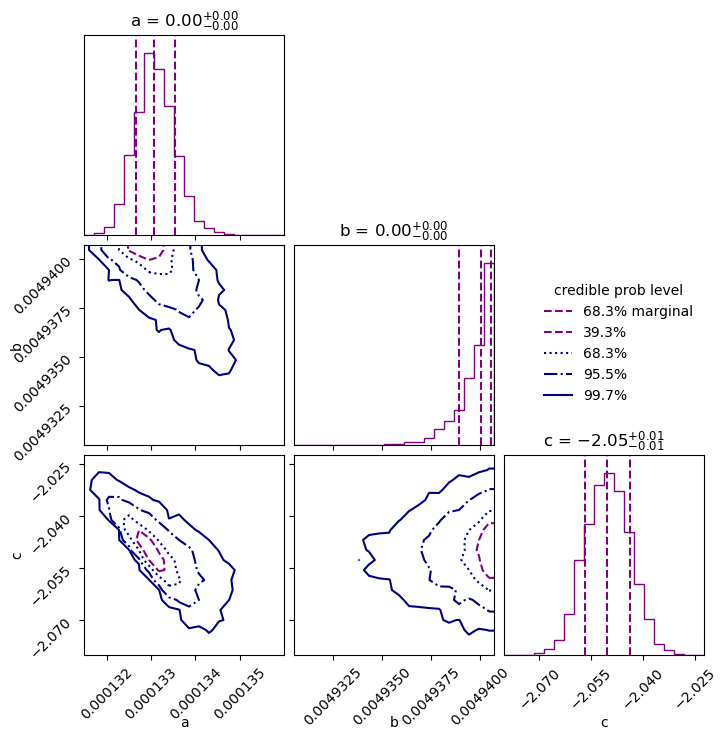

In [67]:
cornerplot(result_air_exponential)

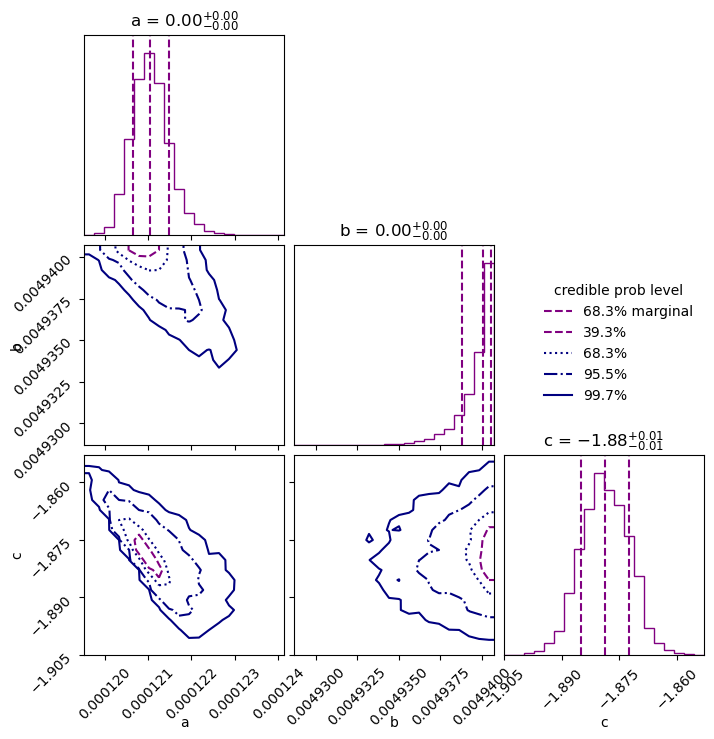

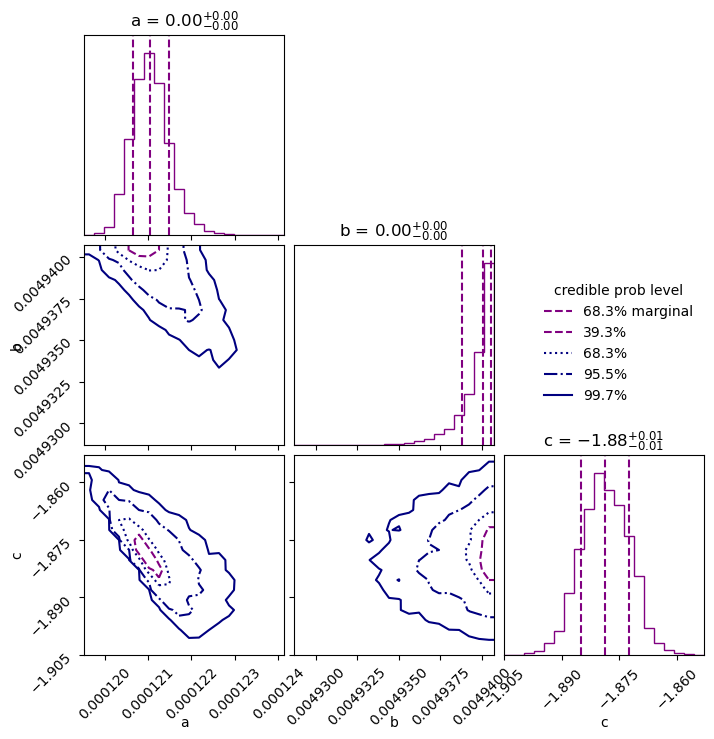

In [68]:
cornerplot(result_water_exponential)

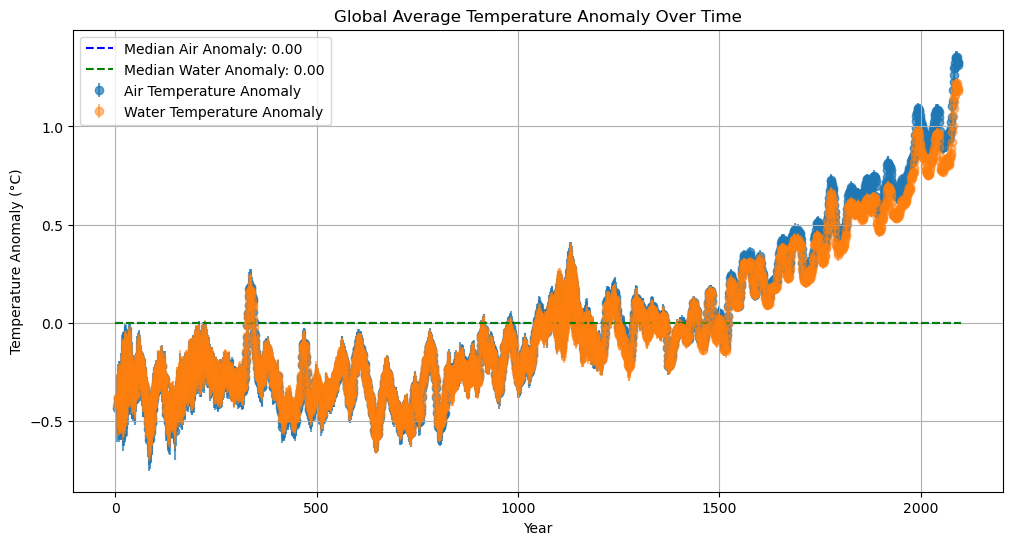

In [ ]:
samples_air = result_air_linear['samples']
samples_water = result_water_linear['samples']

median_air = np.median(samples_air[:, 0])
median_water = np.median(samples_water[:, 0])

plt.figure(figsize=(12, 6))
plt.errorbar(data_air['fake_time'], data_air['Annual_Anomaly'], yerr=data_air['Annual_Anomaly_Unc'], fmt='o', zorder=1, label='Air Temperature Anomaly', alpha=0.7)
plt.errorbar(data_water['fake_time'], data_water['Annual_Anomaly'], yerr=data_water['Annual_Anomaly_Unc'], fmt='o', zorder=2, label='Water Temperature Anomaly', alpha=0.5)
plt.hlines(median_air, data_air['fake_time'].min(), data_air['fake_time'].max(), colors='blue', linestyles='dashed', label=f'Median Air Anomaly: {median_air:.2f}')
plt.hlines(median_water, data_water['fake_time'].min(), data_water['fake_time'].max(), colors='green', linestyles='dashed', label=f'Median Water Anomaly: {median_water:.2f}')
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.title('Global Average Temperature Anomaly Over Time')
plt.legend()
plt.grid()
plt.show()